**NOTA:**

Artur:

1.análise do conjunto de dados e sua breve descrição  ✅

5.análise preditiva/ aprendizagem de máquina (classificação ou regressão conforme apropriado), comparando o desempenho de vários modelos

Maria:

2.tarefas de pré-processamento dos dados (se julgar necessárias)

6.seleção/ importância das variáveis usadas pelos modelos

Catarina:

3.sumarização dos dados (estatística descritiva, exploração com recurso a gráficos)

4.análise estatística multivariada (não supervisionada): clustering, redução de dimensionalidade/ visualização

# **Practical Assignment 2 – Python Application**

# 1. "Analysis of the dataset and its brief description

## 1.1 Introduction
The goal of this practical assignment is to apply data analysis and knowledge extraction techniques to biological data, with a focus on predicting the mutagenicity of chemical compounds. The task involves developing a complete pipeline in Python, including data loading, preprocessing, exploratory analysis, predictive modeling, and performance evaluation.

The dataset used corresponds to the Ames test, a widely adopted biological assay for identifying compounds with mutagenic potential. It includes a matrix of numerical molecular descriptors (features) and a binary label indicating whether each compound is mutagenic (1) or not (0).

This work provides an opportunity to apply several concepts covered throughout the semester, including multivariate analysis, supervised learning, feature selection, and data visualization.

## **Imports**

In [ ]:
import pandas as pd
import numpy as np
import pprint
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mstats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold

## 1.2 Assigment Context - Ames Mutagenicity

### Dataset Description: 

Mutagenicity means the ability of a drug to induce genetic alterations. Drugs that can cause damage to the DNA can result in cell death or other severe adverse effects. Nowadays, the most widely used assay for testing the mutagenicity of compounds is the Ames experiment which was invented by a professor named Ames. The Ames test is a short-term bacterial reverse mutation assay detecting a large number of compounds which can induce genetic damage and frameshift mutations. The dataset is aggregated from four papers.

### Task Description: 

Binary classification. Given a drug SMILES string, predict whether it is mutagenic `(1)` or not mutagenic `(0)`.

## 1.3 Data Exploration with Python

In [ ]:
# Load the features dataset
#features_path = "data_csv\\ames_features.csv"
features_path = "data_csv/ames_features.csv"
features_df = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": features_df.shape,
    "Columns": features_df.columns.tolist(),
    "Missing Values": features_df.isnull().sum().sum(),
    "Preview": features_df.head()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 208)


In [7]:
print("\n Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])


 Feature Columns (truncated list):
['MaxEStateIndex',
 'MinEStateIndex',
 'MaxAbsEStateIndex',
 'MinAbsEStateIndex',
 'qed',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA

In [8]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [9]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.663401,-0.396099,11.663401,0.008895,0.181963,342.310,332.230,342.06406,124.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.824743,-0.170602,11.824743,0.170602,0.269289,301.345,286.225,301.11030,112.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14.431072,-0.378575,14.431072,0.128988,0.184582,646.614,628.470,646.11650,232.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.422196,-0.670278,10.422196,0.248657,0.103849,157.133,150.077,157.05997,60.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.521759,-0.752407,10.521759,0.278148,0.342148,138.086,136.070,138.01778,50.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **Output**

In [11]:
# Load the features dataset
#features_path = "data_csv\\ames_features.csv"
features_path = "data_csv/ames_outputs.csv"
features_df = pd.read_csv(features_path)

# Basic dataset information
features_info = {
    "Shape": features_df.shape,
    "Columns": features_df.columns.tolist(),
    "Missing Values": features_df.isnull().sum().sum(),
    "Preview": features_df.head(),
    "Class Distribution": features_df['Y'].value_counts().to_dict()
}

print("Dataset Shape:")
pprint.pprint(features_info["Shape"])

Dataset Shape:
(7273, 3)


In [12]:
print("Feature Columns (truncated list):")
pprint.pprint(features_info["Columns"])

Feature Columns (truncated list):
['ids', 'smiles', 'Y']


In [13]:
print("Total Missing Values:")
print(features_info["Missing Values"])

Total Missing Values:
0


In [14]:
print("Dataset Preview (first 5 rows):")
features_info["Preview"]

Dataset Preview (first 5 rows):


,ids,smiles,Y
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


In [15]:
print("Class Distribution — 1 = mutagenic, 0 = non-mutagenic:")
pprint.pprint(features_info["Class Distribution"])

Class Distribution — 1 = mutagenic, 0 = non-mutagenic:
{0: 3299, 1: 3974}


## 1.4 Datasets Overview

This project utilizes two datasets derived from the Ames mutagenicity test: one containing molecular features extracted from chemical structures, and another providing binary mutagenicity classification labels.

---

### Dataset Features

This dataset includes computed molecular descriptors and fragment-based features for each compound, derived from its SMILES (Simplified Molecular Input Line Entry System) representation.

- **Rows (samples)**: 7,273 compounds  
- **Columns (features)**: 208 numerical descriptors  
- **Types of features**:
  - *Physicochemical*: `MolWt`, `TPSA`, `LogP`, `qed`, etc.
  - *Topological and electronic*: `Chi`, `BalabanJ`, `EState`, etc.
  - *Structural fragments (binary flags)*: `fr_nitro`, `fr_urea`, `fr_halogen`, etc.

The dataset contains no missing values and is ready for use in machine learning tasks.

---

### Dataset Output

This dataset contains binary classification labels indicating the mutagenicity of each compound, aligned with the compounds in the feature dataset.

- **Rows**: 7,273 (one per compound)
- **Columns**:
  - `ids`: Unique compound identifier
  - `smiles`: SMILES representation of the compound
  - `Y`: Binary label for mutagenicity  
    - `1` = Mutagenic  
    - `0` = Non-mutagenic

#### Class Distribution

| Label             | Count |
|-------------------|--------|
| Mutagenic (1)     | 3,974  |
| Non-mutagenic (0) | 3,299  |

There are no missing values in the output dataset. The class distribution is slightly imbalanced, with more mutagenic than non-mutagenic samples.

---

Together, these datasets form a complete and clean structure for building supervised learning models to predict the mutagenic potential of chemical compounds.


# 2. Data preprocessing tasks

Before fitting any predictive model, we apply a systematic sequence of preprocessing steps to the feature dataset. These steps ensure that the data are clean, consistent, and appropriately scaled for machine learning algorithms.

No missing values were detected in the feature dataset. Therefore, no imputation or NA-specific preprocessing was required.  

In this section, we cover the following stages:

**1. Outlier Handling**

Reduce the influence of rare, extreme measurements.

**2. Low-Variance Feature Filtering**

Drop near-constant descriptors that carry little predictive information.

In [ ]:
X = pd.read_csv('data_csv/ames_features.csv', index_col=0)

### 1. Outlier Handling - Univariate Outlier Detection Across All Features

To identify how many values lie outside the 1st and 99th percentiles for each descriptor, we:

1. **Compute the percentile thresholds**  
   - `q_low` stores the 1st percentile of every column  
   - `q_high` stores the 99th percentile of every column

2. **Count outliers per feature**  
   - We flag values below `q_low` or above `q_high` in each column  
   - Summarize both the raw counts and percentages of outliers

In [28]:
# Compute per-column percentiles
q_low  = X.quantile(0.01)
q_high = X.quantile(0.99)

# Count outliers per column
outlier_counts = ((X < q_low) | (X > q_high)).sum()
outlier_pct    = outlier_counts / len(X) * 100

print("Outliers per feature (count, %):")
print(pd.DataFrame({
    'count': outlier_counts,
    'percent': outlier_pct.round(2)
}))


Outliers per feature (count, %):
                   count  percent
MinEStateIndex       146     2.01
MaxAbsEStateIndex    146     2.01
MinAbsEStateIndex    144     1.98
qed                  146     2.01
MolWt                145     1.99
...                  ...      ...
fr_thiazole            4     0.05
fr_thiocyan            3     0.04
fr_thiophene          58     0.80
fr_unbrch_alkane      65     0.89
fr_urea                6     0.08

[207 rows x 2 columns]


Capping these extreme tails helps stabilize models that are sensitive to range and variance, while retaining all samples.

*Why Winsorization?*
- Winsorization limits extreme values by “clamping” them at specified percentile cut-offs rather than dropping rows.
- For each column, values below the lower percentile are set to that percentile value, and values above the upper percentile are set to the upper bound.

`(0.01, 0.01)`

We measured the 1st and 99th percentiles for each feature and found about 1–2 % of observations lie outside those bounds.
Using limits=(0.01, 0.01) directly matches that analysis, ensuring we only clamp the most extreme ~1 % on each tail.

By integrating this `Winsorizer(limits=(0.01, 0.01))` at the start of our preprocessing pipeline, we ensure each descriptor’s most extreme values are tamed in a principled, reproducible way—providing robust inputs for subsequent power-transformation, scaling, and modeling.

In [31]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_arr = np.asarray(X, dtype=float)
        return np.apply_along_axis(lambda col: mstats.winsorize(col, limits=self.limits), 0, X_arr)

### 2. Low-Variance Feauture Filtering

The `VarianceThreshold` transformer removes any feature whose variance does not exceed the specified threshold. Features with very low variance (i.e., nearly constant across samples) carry little to no predictive information and can be safely dropped.

In [34]:
var_filt = VarianceThreshold(threshold=0.01)

# 3. Data Summarization

In [5]:
# Load the datasets
X = pd.read_csv('data_csv\\ames_features.csv', index_col=0)
y = pd.read_csv('data_csv\\ames_outputs.csv', index_col=0).iloc[:, 0]

# Combine features and labels into a single DataFrame
df = X.copy()
df['Mutagenic'] = y


## 3.1 Descriptive statistics

In [6]:
# Summary statistics for numerical features
summary_stats = df.describe()
print(summary_stats)


       MinEStateIndex  MaxAbsEStateIndex  MinAbsEStateIndex          qed  \
count     7273.000000        7273.000000        7273.000000  7273.000000   
mean        -0.451765           9.362443           0.349721     0.510130   
std          1.227820           3.029246           0.396510     0.167265   
min         -9.055860           1.500000           0.000000     0.036666   
25%         -0.846972           6.209384           0.075424     0.396894   
50%         -0.355799          10.384028           0.211296     0.510491   
75%          0.353001          11.488809           0.510718     0.621552   
max          4.111111          17.286264           4.944445     0.935197   

             MolWt  HeavyAtomMolWt   ExactMolWt  NumValenceElectrons  \
count  7273.000000     7273.000000  7273.000000          7273.000000   
mean    242.568881      229.065451   242.196954            88.108483   
std     107.926752      102.707469   107.731070            39.772440   
min      41.053000       36

In [8]:
print(y.head())
print(y.unique())
print(y.value_counts())
print(df['Mutagenic'].value_counts())


ids
Drug 0    O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...
Drug 1         O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2
Drug 2    O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...
Drug 3                            [N-]=[N+]=CC(=O)NCC(=O)NN
Drug 4                            [N-]=[N+]=C1C=NC(=O)NC1=O
Name: smiles, dtype: object
['O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccccc5c1c2c34'
 'O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2'
 'O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4ccccc4c(=O)c3c3[nH]c4c(ccc5c(=O)c6ccccc6c(=O)c54)c3c12'
 ... 'CCOP(=S)(CC)Sc1ccccc1' 'C=C(C)C1CC=C(C)C(OC(C)=O)C1'
 'CC/N=c1\\cc2oc3cc(NCC)c(C)cc3c(-c3ccccc3C(=O)OC)c-2cc1C']
smiles
[N-]=[N+]=NCC(N)C(=O)O                                          2
COc1cc(NS(C)(=O)=O)ccc1Nc1c2ccc(N=[N+]=[N-])cc2nc2c(C)cccc12    2
[N-]=[N+]=NCC(O)Cn1cnc2c(N)ncnc21                               2
[N-]=[N+]=CC(=O)NCC(=O)NN                                       2
[N-]=[N+]=C1C=NC(=O)NC1=O                                       2
    

## 3.2 Target variable distribution

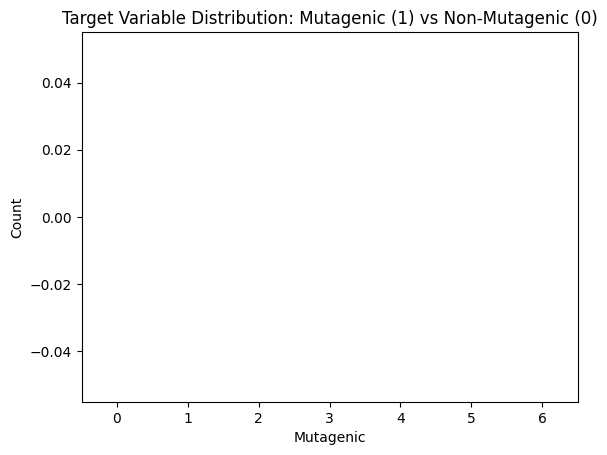

In [7]:
sns.countplot(x='Mutagenic', data=df)
plt.title("Target Variable Distribution: Mutagenic (1) vs Non-Mutagenic (0)")
plt.xlabel("Mutagenic")
plt.ylabel("Count")
plt.show()

## 3.3 Feature distributions

In [ ]:
# Select top 4 features with highest variance
variances = df.var().drop('Mutagenic')
top_features = variances.sort_values(ascending=False).head(4).index

# Plot histograms with class overlay
for feature in top_features:
    sns.histplot(data=df, x=feature, hue='Mutagenic', kde=True)
    plt.title(f"Distribution of {feature} by Class")
    plt.show()


## 3.4 Correlation matrix heatmap

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

# 4. Multivariate statistical analysis (unsupervised)

# 5. Supervised ML

# 6. Variable selection/importance used by the models